In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import detuning
import reinforcement_learning as rl

In [2]:
# --! create cavity environment with detuning --!

dt = 1e-3
t_start = 0.0
t_end = 1.0

mm100_neg = detuning.mechanical_mode(100., 1e3, -0.2, [t_start, t_end])
mm40 = detuning.mechanical_mode(40., 400., 0.1, [t_start, t_end])
mm285 = mechanical_mode(285., 200., 0.15, [t_start, t_end])
mm285_neg = mechanical_mode(285., 200., -0.1, [t_start, t_end])
mm64 = mechanical_mode(64., 100., 0.3, [t_start, t_end])
mm64_neg = mechanical_mode(64., 100., -0.3, [t_start, t_end])
mm10 = mechanical_mode(10., 1e2, 0.1, [t_start, t_end])
mm10_neg = mechanical_mode(10., 100., -0.1, [t_start, t_end])

mm_f=np.array([mm100_neg.f, mm40.f])
mm_q=np.array([mm100_neg.q, mm40.q])
mm_k=np.array([mm100_neg.k, mm40.k])
mm_t=np.array([mm100_neg.t, mm40.t])

# --! prepare parameters for cavity plant simulation
cavity_param = {
    'rf_f' : 1.3e9,
    'rf_q' : 4e6,
    'rf_v' : [9.5, 0.],
    'rf_len' : 0.1615,
    'mm_control_used' : True,
    'mm_f' : mm_f,
    'mm_q' : mm_q,
    'mm_k' : mm_k,
    'mm_t' : mm_t,
}

# --! define state and action cost
state_cost = [1.0, 0.1]
state_max = [1.0, 100.0]
action_cost = 10.0
action_max = 1.0
setpoint = 0.0

reward_fn = detuning.detuning_reward(
    np.diag(np.tile(state_cost, len(mm_f))),
    np.diag([action_cost]),
    np.ones(2 * len(mm_f)) * setpoint)
env = detuning.detuning(cavity_param, reward_fn, dt_dynamics=1e-5, dt_control=dt, t_end=t_end)
env = detuning.detuning_adapter(env)


In [3]:
# --! make a base policy --!

est_q = 1.0
est_r = 1.0

# --! introduce mismatch between real plant and controlled plant
policy_f = mm_f[:1]
policy_q = mm_q[:1]
policy_k = mm_k[:1]

base_policy = detuning.make_base_policy(
    policy_f, policy_q, policy_k, dt,
    setpoint,
    state_cost, state_max,
    action_cost, action_max,
    est_q, est_r)


In [4]:
replay_factory = detuning.replay_factory()

env_ic = torch.zeros(1, 1, 2 + 2 * len(mm_f))
nsample = 64
replay = replay_factory.create(env, env_ic, rl.policies(base_policy, None), nsample, skip_nsample=0)


>>> replay factory: skipping 0 samples


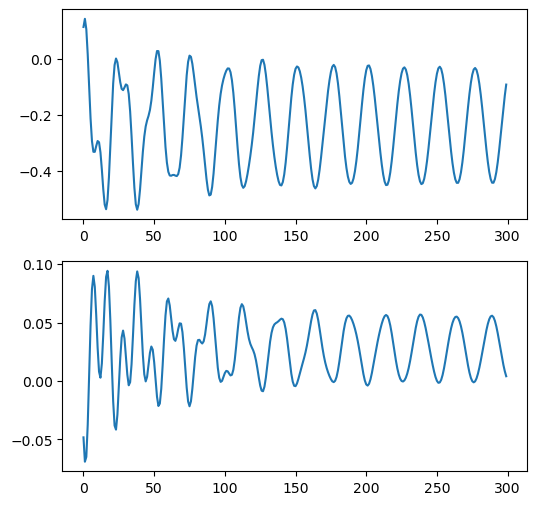

NameError: name 'tata' is not defined

In [5]:
back, _, _, _ = map(torch.cat, zip(*replay.buffer))
obs = back[:, [-1]]

with torch.no_grad():
    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(obs[:300, 0, 0])

    plt.subplot(2,1,2)
    plt.plot(obs[:300, 0, 1])

    plt.show()

print(tata.shape)